# WETH/USDC Realistic Simulator

**Goal:** an end-to-end simulator of the Uniswap V3 5bp WETH/USDC pool whose retail outcomes match on-chain reality.

**Structure.** §1 and §2 show that the realistic simulator's *primitives* (price returns, retail order arrivals and sizes) match the empirical distributions where the Simple AMM Challenge defaults don't. §3 introduces the two-pool architecture. §4 calibrates the one free piece of that architecture — the V2 *normalizer pool* that represents the rest of the market — against the realized non-5bp retail impact curve. §5 validates the calibration against retail-only outcomes on the 5bp pool, which never feed into the fit. §6 reads the validation. §7 turns the retail-sample choice into a robustness dial (conservative ↔ aggressive). §8 recalibrates the normalizer to the *whole* current on-chain market — the competitor a new submission strategy is tested against.


In [1]:
import sys, os, importlib

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

# Reload helpers so re-running this cell picks up edits without a kernel restart.
import helpers
importlib.reload(helpers)
from helpers import *
%matplotlib inline

---
## Section 1: Return Distributions

The Simple AMM Challenge uses a **Geometric Brownian Motion** (GBM) model for price returns. Real ETH/USD returns (measured from Binance order book at 12-second intervals) exhibit heavier tails and regime-dependent volatility that GBM cannot capture.

Our realistic simulator uses a **5-regime Markov-switching process** fitted to empirical return quantiles.

In [2]:
observed_90d = load_binance_quantiles("90d")
challenge_rets = generate_challenge_return_quantiles()
realistic_rets = generate_realistic_return_quantiles()

### Chart 1a: Challenge (GBM) vs Observed Returns

The GBM model is too concentrated around zero — it underestimates the probability of large price moves.

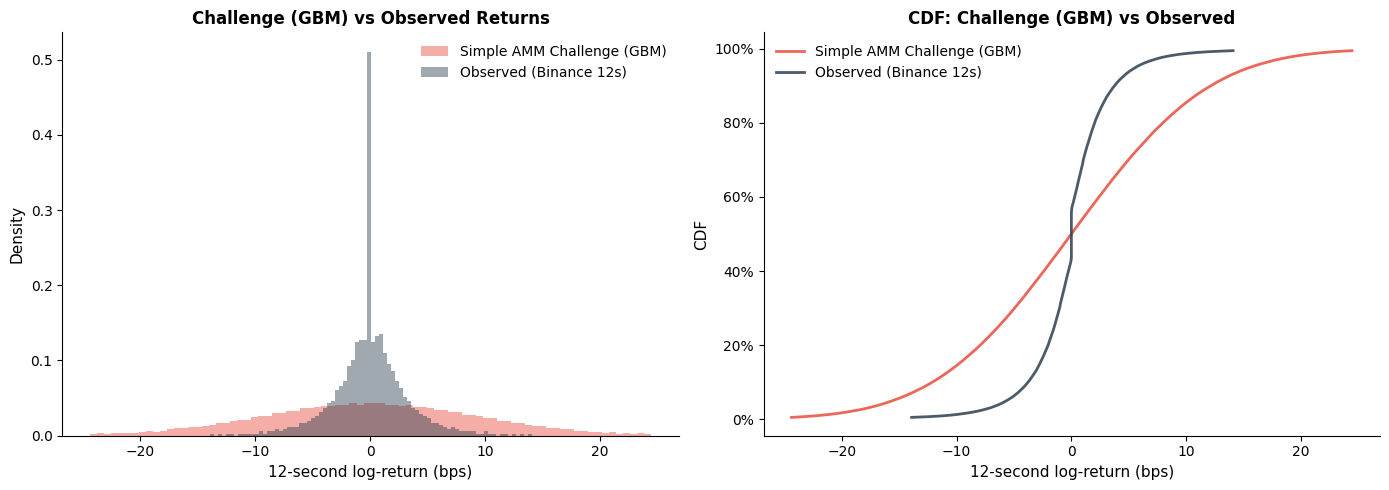

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="Challenge (GBM) vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="CDF: Challenge (GBM) vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 1b: Realistic Simulator vs Observed Returns

The regime-switching model closely tracks the empirical distribution, including the heavy tails.

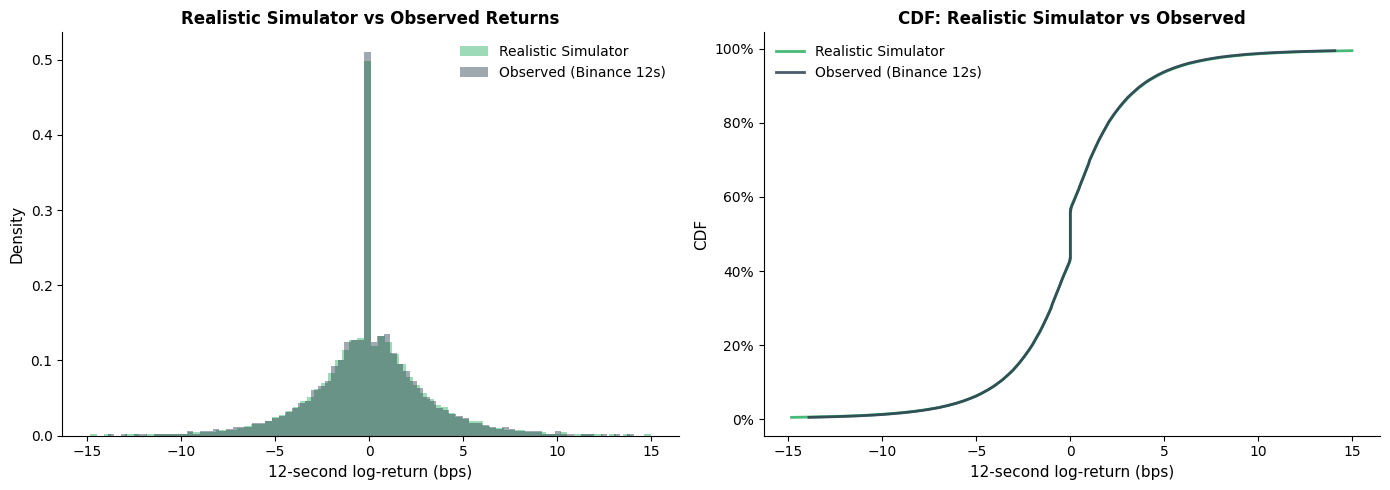

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="Realistic Simulator vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Robustness: Consistent Across Lookback Windows

The observed distribution is stable across 90-day, 180-day, and 360-day windows.

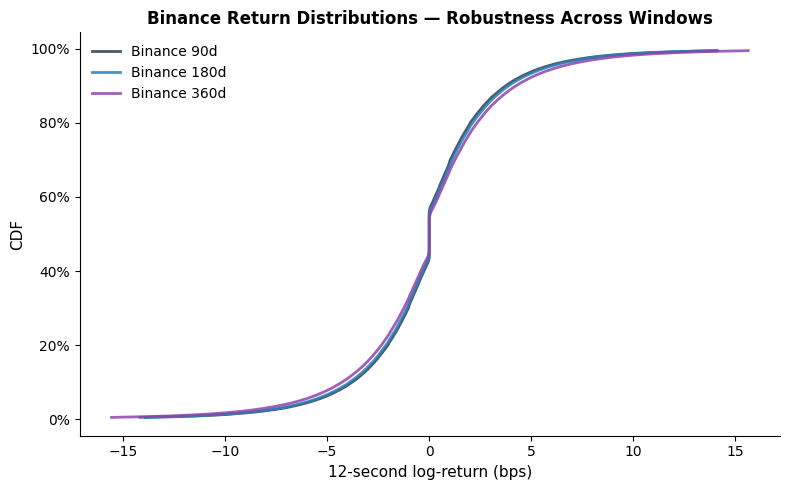

In [5]:
plot_return_robustness()
plt.tight_layout()
plt.show()

---
## Section 2: Retail Order Arrival & Size Distribution

The Challenge uses a **Poisson process** (rate=0.8/block) with **lognormal order sizes** (mean ≈ $20, σ = 1.2). Real retail flow looks nothing like that. We now measure it on the **same strict-retail cohort used for calibration (§4) and validation (§5)** — transactions from a known end-user front-end: the **Uniswap first-party app** (web / mobile / extension, via the `core.swaps` surface tag) ∪ **MetaMask Swaps** (87.5 bps fee) — over the 30-day window 2026-04-21..05-20.

Our realistic simulator samples **USD order sizes directly** from this strict empirical parent-order distribution, at the observed strict arrival rate (**~0.46/block**: 98,676 parent orders / 216,000 blocks). The broad 19-router cohort (~0.66/block) is retained for robustness checks but is no longer the primary sample.

### Chart 2a: Arrival Rates

The realistic simulator's arrival rate (~0.46/block) is matched to the observed strict-retail rate by construction. The Challenge's fixed 0.8/block is calibrated to nothing in particular and overstates strict-retail arrivals by ~75%.

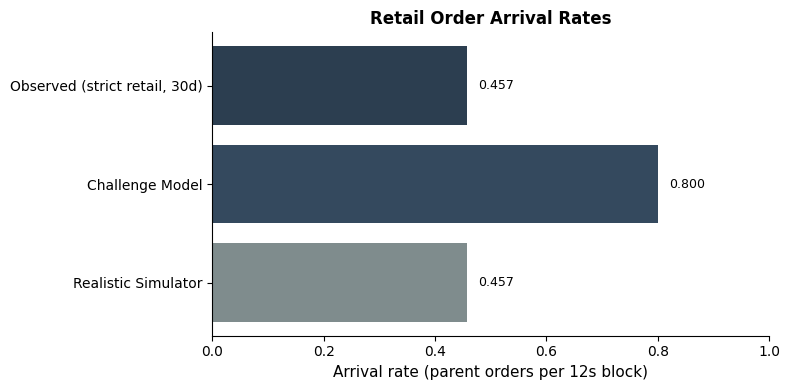

In [6]:
plot_arrival_rate_comparison()
plt.tight_layout()
plt.show()

In [7]:
observed_retail = load_strict_retail_quantiles()
challenge_retail = generate_challenge_retail_quantiles()
realistic_retail = generate_realistic_retail_quantiles()

### Chart 2b: Challenge (Lognormal) vs Observed Order Sizes

The lognormal model concentrates mass around $20 and completely misses the heavy right tail of real orders.

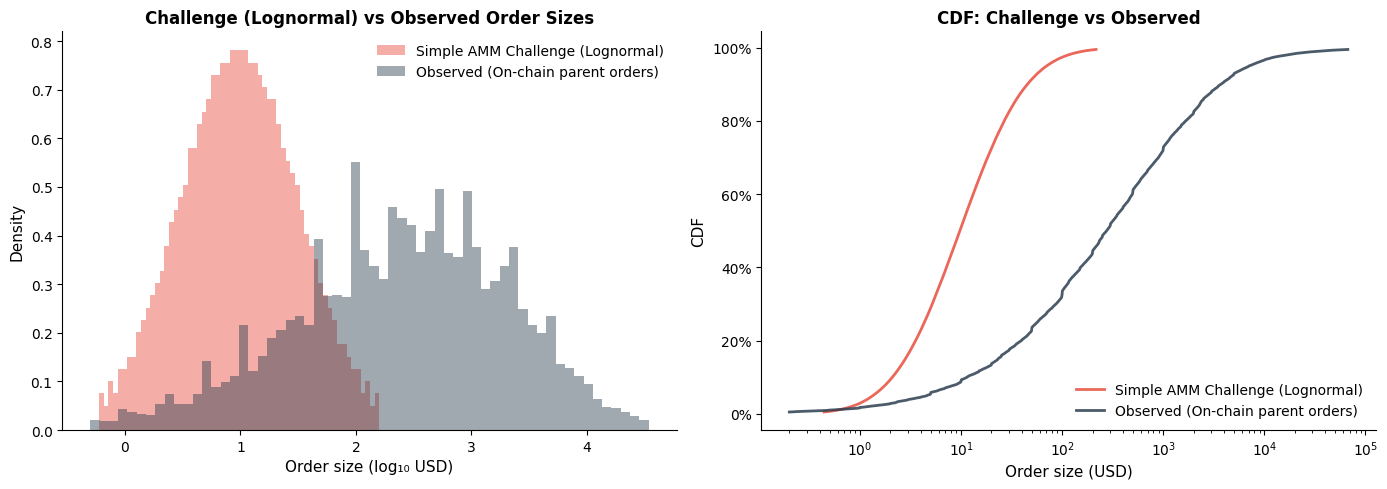

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="Challenge (Lognormal) vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="CDF: Challenge vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 2c: Realistic Simulator vs Observed Order Sizes

The empirical USD-size model closely matches the observed strict-retail parent-order distribution (the sim samples directly from it). Critically, the strict cohort's size tail tops out near **$1.4M — no multi-million-dollar whale trades** — which is what fixes the LP-markout overshoot seen with the broad cohort (see §6).

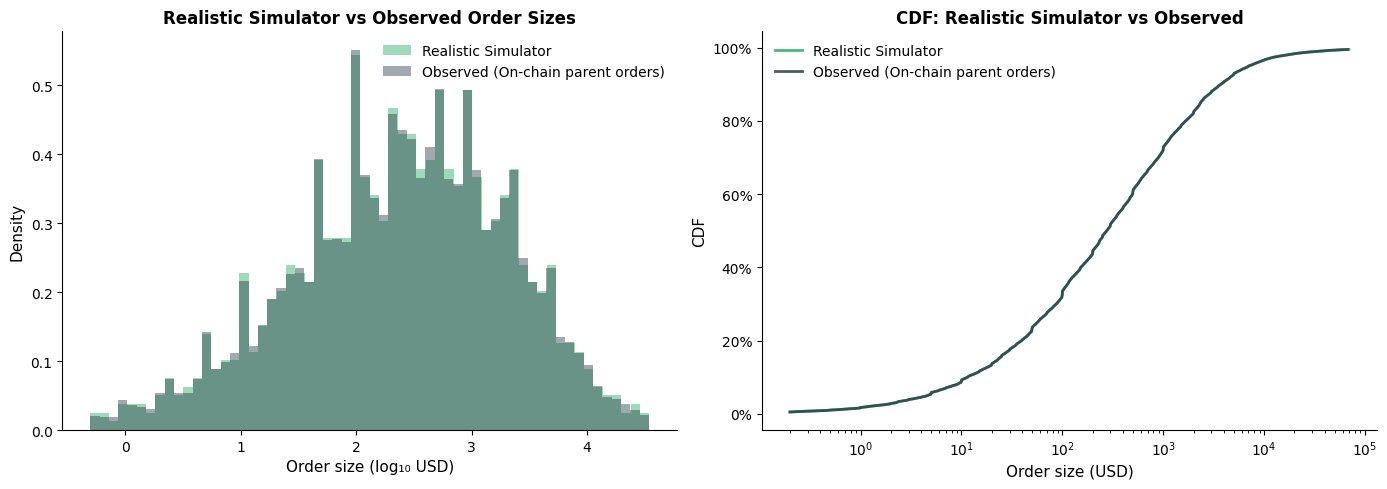

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="Realistic Simulator vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

---
## Section 3: Two-pool architecture

The simulator models the WETH/USDC market as two pools:

- **Submission pool.** The real Uniswap V3 5bp pool, **frozen** at its on-chain configuration: `fee = 5 bps`, `virtual_depth_y = $212.16M` USDC. No free parameters. Arbitrageurs trade against it each step to pull its mid toward the prevailing fair price.
- **Normalizer pool.** A single hypothetical V2 (constant-product) pool that represents *everything else* — V4 1bp + 30bp, V3 30bp, V2, Curve, Balancer, etc. Two free parameters: spread **φ** (proportional fee) and depth **D** (USDC-side).

**The normalizer is held at fair, not arbed.** At the top of every step the normalizer's mid is re-synced directly to the current fair price at constant USDC depth `D` (`reserve_y = D`, `reserve_x = D/fair`). It therefore represents the *efficient* rest-of-market — always correctly priced the instant retail arrives — and **no arbitrage ever hits it**. (Previously the normalizer was a live pool dragged toward fair by a per-step arb; that left it slightly stale between arbs and made its price depend on arb timing. Snapping it to fair removes both artifacts.) Only the 5bp submission pool is arbitraged.

Each retail order is **split across both pools to equalize their marginal execution price** (the closed-form two-AMM optimal split in `OrderRouter.split_buy/sell_two_amms`) — not routed wholesale to a single venue. The deeper / cheaper pool simply receives the larger share. The normalizer's `(φ, D)` is the only thing we calibrate.

---
## Section 4: Calibrating the normalizer pool

**Target.** The empirical price-impact curve of **strictly-retail** transactions across **all non-5bp** WETH/USDC venues, referenced against the **prevailing fair price one 12s step before the trade** (the real-data analog of the simulator's "1 step before"). For each tx we measure:
- `size_usd` — total USD traded across the tx's non-5bp legs (any venue)
- `spread_bps` — `1e4 × (effective_price − fair_lag) × side / fair_lag`, where `fair_lag` is the fair price at or before 12s before the trade.

**Why all non-5bp venues (not just V3).** The normalizer is the competitor the held-out 5bp pool is validated against — and the 5bp pool competes against **every** other pool on the pair, not just the V3 ones. An earlier version of this sample was **V3-only**, which dropped the ~10% of non-5bp flow on V4 / Fluid / Balancer / Curve / … and biased the fit. Because the calibration target is the lagged Binance mid (below), it needs only the routed order amounts — not any per-pool mid — so we build it straight from `markout_prod` across all venues. This is the **same build as the §8 full-market sample, just excluding the 5bp pool**: §4 = all venues *minus* 5bp (5bp is the submission pool being validated), §8 = all venues *including* it.

**Why a strict-retail filter.** The normalizer pool exists to be a realistic *retail* competitor to the submission pool — the question it answers is how retail order routing reacts to changes in the new pool. So it is calibrated to flow that is unambiguously human retail on a known front-end, not the broad router-level superset (which mixes in MM execution, arb bots, and aggregator flow). The cohort is the **union of two front-end sources**:
- **Uniswap first-party front-end** (web app + mobile wallet + extension) — from `uniswap-labs.core.swaps`, which materializes the off-chain `x-request-source` surface tag and the tx hash. There is *no* on-chain marker for interface flow (Uniswap dropped the web/mobile swap fee at UNIfication 2025-12-27, and web/mobile build byte-identical calldata), so this internal surface attribution, joined by tx hash, is the only clean signal. It is the dominant retail source.
- **MetaMask Swaps** — txs that paid the **87.5 bps** convenience fee to `0xf326e4…f1915` (Etherscan "MetaMask: DS Proxy"; ~87.9 bps empirically).

The two surfaces are disjoint (zero tx overlap). A 25 bps collector `0xcd6b98…` that initially looked like a Uniswap interface fee turned out to be **Rabby Wallet**, not Uniswap, and is excluded.

**Why lagged fair (not pool mid, not contemporaneous fair).** This matches the normalizer's role in §3: retail trades against a pool sitting at the prevailing fair, so we calibrate impact *relative to fair*. We use a **pre-trade** fair (one 12s step stale) so the reference cannot have been moved by the trade's own impact. The cost is noise — each trade's spread also carries ~12s of price drift — so the USD-weighted **Huber** loss (Plan B) is the robust default. The all-venue sample (from `markout_prod`) carries the contemporaneous-fair spread as a diagnostic, but **no per-pool mid** — so pool-mid-based sandwich detection lives on the V3 subset only (Chart 3b).

**Fair-price source.** The Binance book table only covers 2023-04..2025-11, so the fair series is reconstructed from `markout_prod.benchmark` over all WETH/USDC swaps (last observation per 12s bucket, forward-filled), and each trade reads the bucket immediately preceding its own. See `analysis/weth_usdc_90d/sql/non5bp_allvenue_impact_30d.sql`.

**Universe & window.** All non-5bp WETH/USDC swap legs across every venue, aggregated per tx, restricted to the strict-retail cohort, over a **30-day window (2026-04-21..2026-05-20)**: **~92K transactions**. The retail trades span up to ~$379K (median ~$430; **none ≥ $1M** — no whales; in fact the biggest retail trades all route at least partly through the deep 5bp pool, so excluding it caps the non-5bp tail at ~$379K). The range is wide enough that the impact slope is clearly visible, so **D is well-identified** — Plan A (L2) and Plan B (Huber) independently agree on D ≈ $73–79M.

**Model.** A V2 constant-product pool with fee φ and depth D has retail-side spread

$$\text{spread} = \frac{\varphi + (1-\varphi)\,S/D}{1-\varphi}\,.$$

**Loss.** USD-weighted Huber on residual spread (`scripts/calibration/fit_impact_curve_pool_mid.py`, Plan B; δ = 90th percentile of |residual| under the USD-weighted-L2 Plan A). We default to Plan B below: **φ = 3.68 bps, D = $73.4M** (vs the old V3-only fit's φ = 2.18 bps, D = $63.9M — the higher floor reflects the higher-fee non-V3 tiers now included).

In [10]:
fit = load_impact_curve_fit()
phi_b   = fit['plan_b']['phi']
depth_b = fit['plan_b']['depth_usdc']
print(f"Plan B fit")
print(f"  φ      = {phi_b*1e4:.3f} bps")
print(f"  depth  = ${depth_b/1e6:,.1f}M USDC")
print(f"  n_txs  = {fit['n_txs']:,}")
print(f"  window = {fit['window']}")


Plan B fit
  φ      = 3.675 bps
  depth  = $73.4M USDC
  n_txs  = 91,655
  window = 2026-04-21..2026-05-20


### Chart 3a: Empirical impact curve + V2 fit (all non-5bp venues)

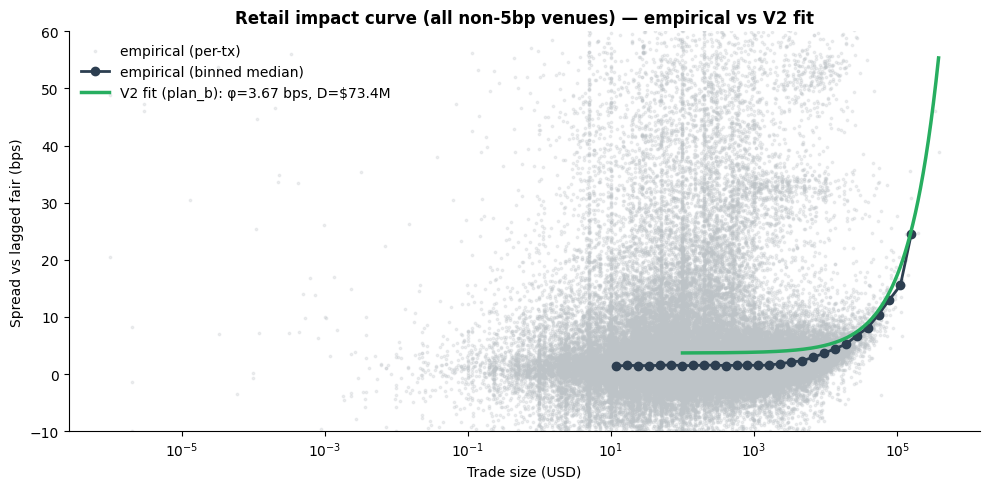

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b')
plt.tight_layout()
plt.show()


### Chart 3a (by venue): what is the elevated band above the V3 mass?

Chart 3a shows a diffuse band of points sitting ~25–35 bps **above** the V3 calibration mass (which hugs ~2 bps). Colouring each tx by its dominant venue + version — with the per-venue median (◆) — shows the band is **fixed-fee venues, not price impact.** Three findings, each with the pool's fee read **on-chain**:

**1 — A flat ~28–33 bps fee-tier band: the non-V3 venues the old V3-only sample omitted.** A fixed-fee pool sits at ~its fee regardless of trade size (flat), unlike an impact curve (rising):

| Venue (verified) | Prominent pool(s) | Fee (on-chain) | Median spread | venue n |
|---|---|---|---|---|
| **Uniswap V2** | `0xb4e16d…` — the USDC/WETH pair (all V2 flow) | 30 bp (V2 fixed) | ~25 bps, flat | 5,007 |
| **Curve** | `0x70c517…` cryptoswap `fee()`=33bp; `0x89c971…` StableSwap-NG `fee()`=28bp | 28–33 bp | ~32 bps, flat | 210 |
| **Balancer V3** | `0xe0af30…` Gyroscope E-CLP, swap fee 28 bp | 28 bp | ~32 bps, flat | 282 |

The band totals **5,499 txs = 6.0% of trades, 3.8% of USD**, and **by count is overwhelmingly the Uniswap V2 30bp pair** (`0xb4e16d…`); Curve + Balancer add a thin higher-fee fringe. Every one of these spreads is **flat across trade size** (e.g. Curve `0x70c517` reads 32.9 → 33.0 → 32.1 bps from $1K to $250K) — the fingerprint of a swap fee, not mechanical impact.

**2 — Uniswap V4 is mostly *low*-fee, so it joins the cheap mass, not the band.** All V4 swaps collapse to the PoolManager singleton `0x0000…4444` (fee tiers live in the poolId, not the address); its WETH/USDC flow concentrates in the 1bp / 5bp / dynamic-fee-hook pools (per-pool realized spread 1–6 bps, rising with size like impact). V4 is **17.8% of txs at a 3.8 bps median** — it sits *inside* the calibration mass. Only a thin 30bp V4 pool throws off a few high-spread points (the ~35 bps median over its 78 txs is MEV, not a fee tier).

**3 — The very top of the cloud (~40–55 bps, red) is the Uniswap V3 1bp pool's wide-vs-fair tail.** A 1bp fee can't produce 40+ bps, so these are execution-vs-lagged-fair outliers (1,479 txs). Cross-checked against the V3 sample: **~⅓ (473) are genuine sandwich/MEV victims** — the Chart 3b red cluster — and **~⅔ are 12s-lagged-fair drift noise** (the trade filled at ~the pool mid, which tracked fair, but the *stale* fair reference had moved). Both were already in the V3-only chart; Chart 3b below isolates the true-sandwich third.

**Does it move the fit? Barely — and correctly.** The fee-tier band is real cost retail pays on those venues, but it is 6% of trades / 3.8% of USD; the USD-weighted Huber fit is anchored by the 1bp-pool + V4 low-fee mass (94% of flow, ~2 bps). The band lifts the blended floor only slightly — which is exactly the φ = 2.18 → 3.68 bps move from adding the non-V3 venues.

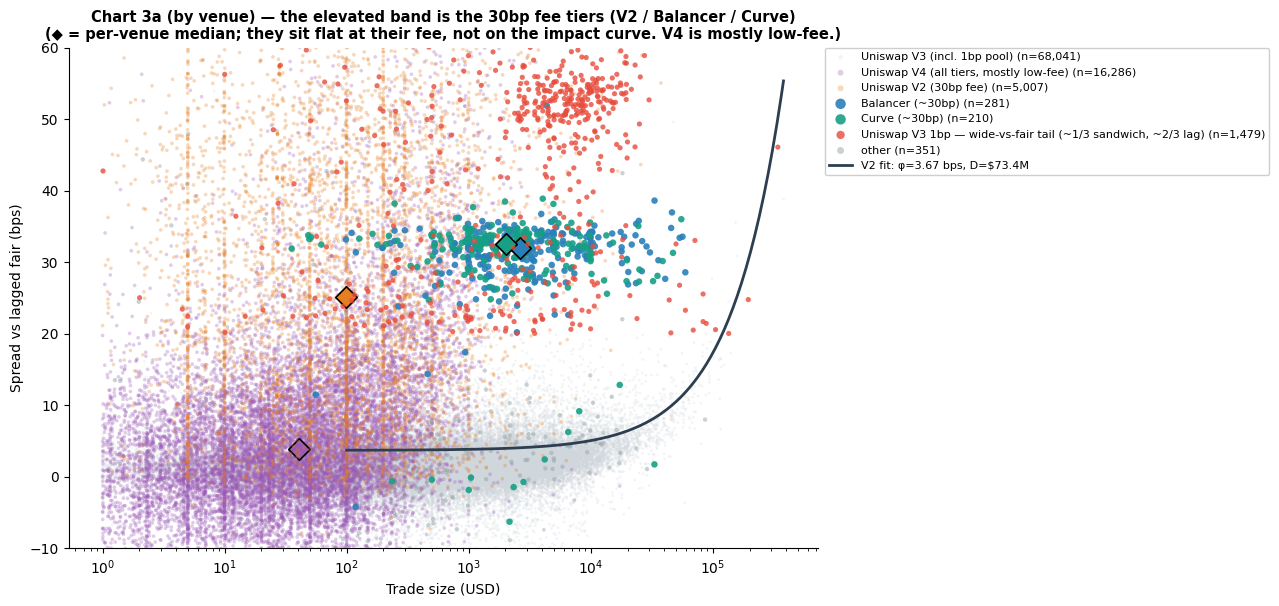

In [12]:
fig, ax = plt.subplots(figsize=(14, 6.5))
plot_impact_curve_by_venue(ax=ax)
plt.show()

**Sandwiches — a V3-subset diagnostic (Chart 3b).** The all-venue calibration sample above comes from `markout_prod`, which carries no per-pool pre-trade mid, so sandwich victims can't be color-coded on it. On the **V3 subset** — where each pool's `sqrtPrice` gives a pre-trade mid — the signature is visible (red below):

a trade fills against a pool whose **pre-trade mid was already pushed off fair** — the on-chain sandwich / transient-MEV-excursion signature. Verified on same-block traces: a *separate* frontrun tx earlier in the block pushes the pool 10–68% off fair, the retail trade fills at that pushed price, and a backrun restores the pool within the same block. (This is why these trades look cheap vs the pool's own pre-trade mid — `pool_mid_pre` = the frontrun's price — but expensive vs an external CEX fair.)

**Rule** — applied to every trade in the V3 sample (not just the visible cluster). A trade is flagged *sandwiched* when:

```
|pool_mid_pre_blended / fair_price_blended − 1| > 0.5%   AND   |observed_spread_pool_bps| < 20 bps
```

i.e. the pool's pre-trade mid sat more than 0.5% (50 bps) from the contemporaneous fair, while the fill itself executed within 20 bps of that pushed mid — a *victim* of the push, not a trade that moved the pool with its own size. This flags **473 of ~70K** V3 trades (mostly the 1bp pool `0xe0554a…`, largely memecoin multi-hop routes that touch WETH/USDC as a hop).

These are **MEV slippage, not the pool's mechanical impact**, which is why they sit above the V2 fit. The USD-weighted Huber loss down-weights them in either sample, so the fitted `(φ, D)` is robust to them whether or not they're flagged.

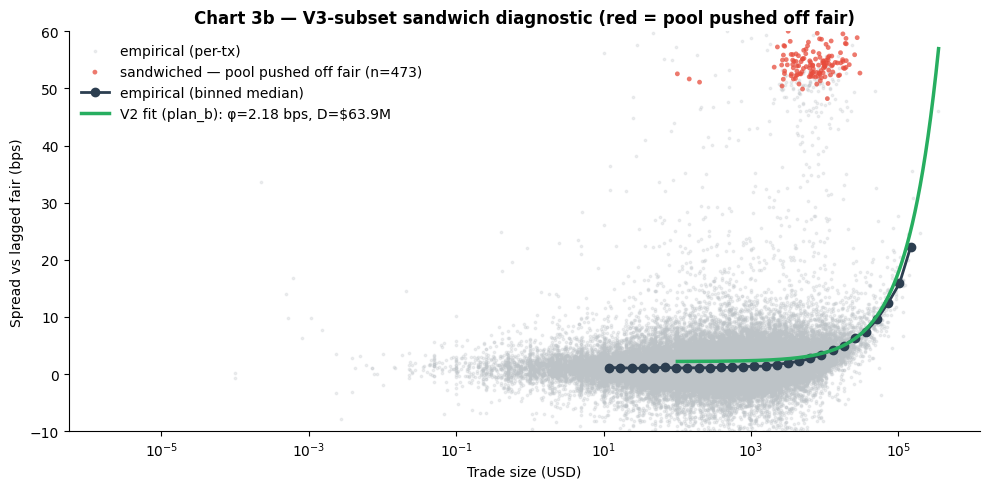

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b',
                      sample=load_impact_curve_sample_v3(),
                      fit=load_impact_curve_fit_v3(),
                      title="Chart 3b — V3-subset sandwich diagnostic (red = pool pushed off fair)")
plt.tight_layout()
plt.show()

---
## Section 5: Held-out retail validation

We now run the simulator with the calibrated normalizer and the frozen 5bp submission pool, and compare three **retail-only** outcomes against on-chain reality. Crucially, none of these metrics fed into the fit — they are genuinely held out.

We focus on retail because the arb side carries no free parameters: only the 5bp submission pool is arbitraged (the normalizer is held at fair by construction, §3), and that arb is closed-form and deterministic. The retail-side metrics carry the signal about whether the normalizer pool's `(φ, D)` is correct.

**Metrics**
1. **Retail volume share at 5bp** = `retail_vol_5bp / retail_vol_total`.
2. **Retail fee share at 5bp**    = `retail_fees_5bp / retail_fees_total`.
3. **USD-weighted retail markout_15s distribution** at the 5bp pool. Convention: `markout_15s` for LP profitability (15 seconds is the standard horizon); USD-weighted percentiles emphasize the large trades that drive LP P&L.

**Real numbers** are pulled from `dex_trades` (volume + fees) and `markout_prod` (per-swap markouts) over the same 30-day window, on the **same strict-retail cohort** (Uniswap first-party FE ∪ MetaMask) used for calibration and the size distribution — so sim and real describe the identical population (the symmetry §7 argues for). See `sql/retail_5bp_share_strict_30d.sql` and `sql/markout_5bp_pool_strict_30d.sql`. (The broad 19-router builders are kept for robustness.)

**Sim numbers** are produced by `scripts/calibration/validate_pool_mid.py` with five seeds × 5,000 steps. Per-trade sim markouts use the next-block `fair_price` (~12s — closest available proxy for the 15s real reference).

In [14]:
validation = load_validation()
get_validation_summary_table()


,Metric,Real (on-chain),Simulator
0,Retail volume share @5bp,45.89%,55.09% ± 1.02pp
1,Retail fee share @5bp,17.36%,62.53% ± 0.97pp
2,Retail markout_15s — USD-w mean,+9.71 bps,+5.02 bps
3,Normalizer φ,—,3.67 bps
4,Normalizer depth,—,$73.4M
5,Submission pool fee,5.00 bps (frozen),5.00 bps (frozen)
6,Submission pool depth,$212.2M (frozen),$212.2M (frozen)


### Chart 5a: Retail volume / fee share at 5bp pool


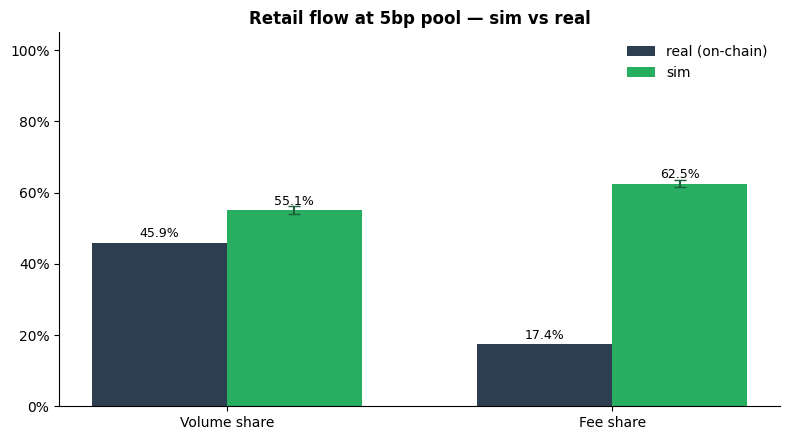

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_retail_share_bars(ax=ax)
plt.tight_layout()
plt.show()


### Chart 5b: Retail markout_15s on 5bp pool — USD-weighted


/Users/xinwan/Github/amm-gym/presentation/helpers.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=False)


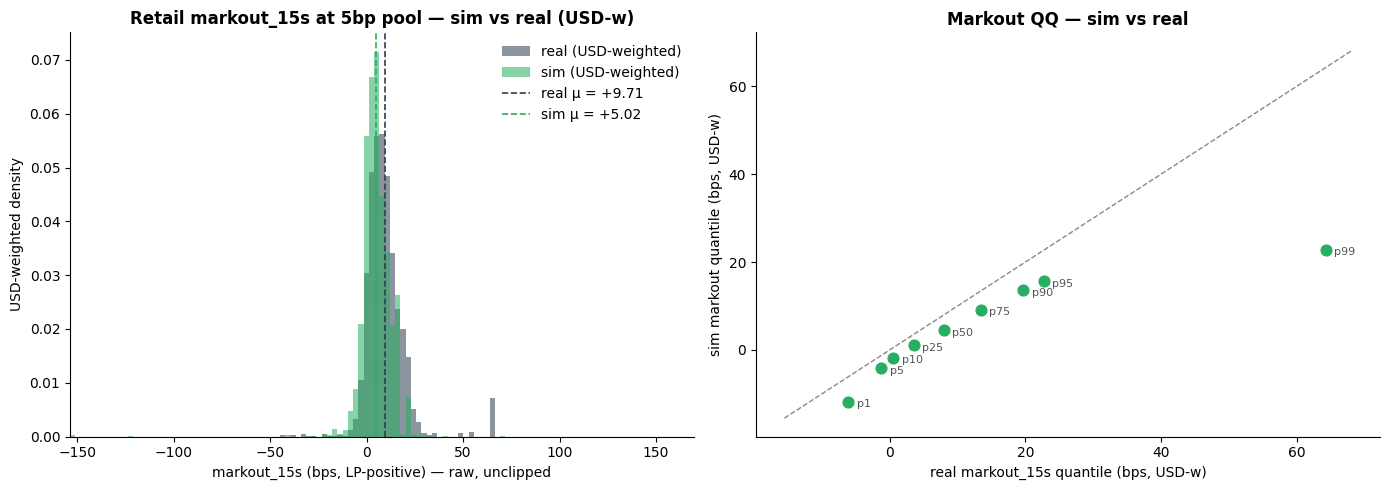

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_retail_markout_overlay(ax=ax1)
plot_retail_markout_qq(ax=ax2)
plt.tight_layout()
plt.show()


---
## Section 6: Reading the validation

**Caveat on the real-world numbers.** This is the *cleaned, strict-retail* validation. An earlier version included two Wintermute MM contracts in the retail-router list; with them in, retail volume share at 5bp looked like 78% and markout like −3 bps, and the sim spuriously "matched." After the router cleanup — and a further shift of **all three samples (size distribution §2, calibration §4, validation §5) onto a single strict end-user front-end cohort** (Uniswap first-party FE via `core.swaps` ∪ MetaMask 87.5bps fee, 30d) — sim and real describe the *identical* population. (The broad 19-router method is kept for robustness.)

**How the model is specified now.**
1. **Normalizer held at fair, not arbed (§3)** — snapped to current-step fair at constant depth `D`; no arb touches it.
2. **Calibrated to lagged pre-trade fair on strict-retail *all-non-5bp-venue* flow (§4)** — φ = 3.68 bps, D = $73.4M, well-identified. (This is the corrected competitor; the earlier V3-only fit was φ = 2.18 bps, D = $63.9M.)
3. **Size distribution, arrival rate, buy share, and validation targets all on the same strict cohort** — arrival ~0.46/block, buy share 0.46, size tail topping out near $379K (no whales).

**Markout — matched, and stable under the correction.** This was the headline gap. Strict real USD-weighted retail markout_15s is **+9.7 bps**; the sim shows **+5.0 bps** (Δ −4.7 pp), essentially unchanged from the V3-only normalizer's +5.3 bps — the normalizer's φ has little leverage on the 5bp pool's *own* markout, which is driven by the size distribution and the 5bp impact. (Down from +58 bps under the old broad size distribution: the strict tail produces **0 sim trades ≥ $1M**, vs the broad cohort's $5M whales that marked out ~+250 bps each.) The sim slightly *undershoots*, consistent with real strict-retail being marginally more profitable to the LP than the uninformed sim flow.

**Volume share — now overshoots, and that is informative.** Strict real retail routes ~45.9% of WETH/USDC flow to the 5bp pool; the sim routes **~55.1%** (Δ +9.2 pp), up from ~48.9% under the V3-only normalizer. The *correct* all-venue competitor has a higher fee floor (φ ≈ 3.7 vs 2.2 bps), which makes the 5bp pool look relatively cheaper, so the sim sends it more flow. The V3-only fit happened to match volume share better (Δ ~+3 pp) but it was the **wrong competitor** — it dropped ~10% of non-5bp flow. The overshoot is the real lesson: a single blended-φ V2 can't simultaneously serve **volume routing** (which keys off the cheapest *marginal* venue — the 1bp V3 pool) and **impact/markout** (which keys off the volume-blended curve). The blended fit is right for markout and overstates the competitor's price for routing.

**Fee share — still fails large.** Strict real retail pays only ~17% of its WETH/USDC fees at the 5bp pool; the sim produces **~63%** (down from ~69%, but still inverted). A single V2 normalizer at φ ≈ 3.7 bps is *cheaper* than the 5bp pool, while in reality the rest-of-market fee revenue is dominated by high tiers (V4 / V3 30bp, Curve, …) and is *more* expensive than 5bp. One φ can't reproduce that mix.

**Takeaway.** With the corrected all-venue normalizer the simulator still matches real retail on markout (within ~5 bps). Volume share now overshoots by ~9 pp and fee share remains structurally off — both for the same reason: collapsing a heterogeneous multi-tier market into one blended-φ V2 pool. A **multi-tier normalizer** (a few pools at the real fee tiers sharing the order flow) is the single change that would fix both, and is the higher-leverage next step over any further cohort filtering.

---
## Section 7: Retail-sample robustness

All three uses of real retail data — the size distribution (§2), the calibration (§4), and the validation (§5) — now sit on **one cohort**: transactions from a known end-user front-end (Uniswap first-party app via the `core.swaps` surface tag ∪ MetaMask Swaps' 87.5 bps fee). Calibrating, sizing, and validating on the *same* population is what makes the comparison apples-to-apples. (An earlier per-transaction audit confirmed the broad 19-router cohort mixes in MM / whale / arb flow. The size distribution is the use most sensitive to that contamination — it's why the strict shift collapsed the sim markout from +58 to +5 bps — while the impact-curve calibration is the least sensitive, since AMM mechanics don't depend on trader identity.)

**The catch: the strict cohort is a _subset_ of true retail.** It captures only two front-ends, so it almost certainly **understates the arrival rate**, and its size tail (capped ~$1.4M) is thinner than the broad cohort's (~$7M) — we likely **understate large-order frequency** too. The true distribution is unknown, and chasing it is a rabbit hole.

So rather than pick a single "best" sample, treat the retail assumption as a **dial**. We anchor on the strict cohort (conservative) and the broad 19-router cohort (aggressive) and interpolate the arrival rate and order-size quantiles between them. The sweep below shows how the validation metrics move across that range; the slider lets you set the assumption yourself and re-run the sim.

**Takeaway.** Volume share and especially markout are sensitive to the retail-size assumption — markout ranges from ~+5 bps (conservative) to ~+80 bps (aggressive) as the size tail fattens — so read the sim's absolute markout as a *band*, not a point. **Fee share stays ~68–75% across the whole range**: that's a structural normalizer-fee-mix gap, not a sampling artifact, and it's the one conclusion that holds regardless of where you set the dial.

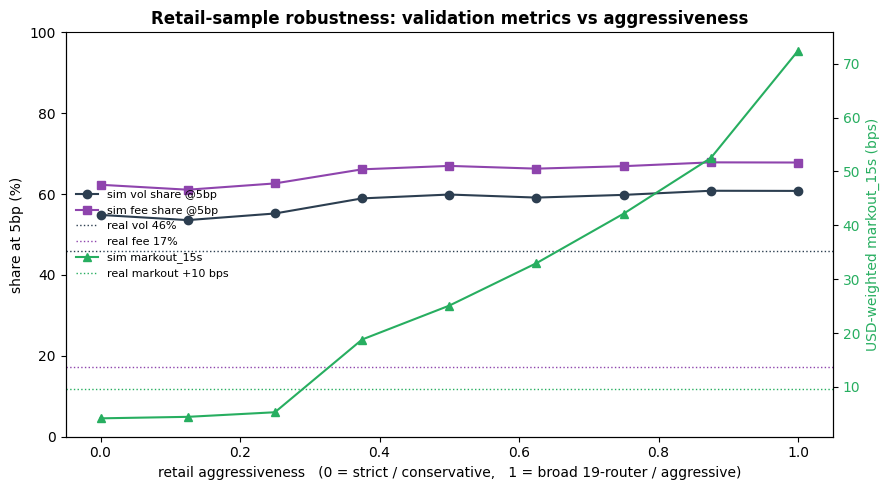

In [17]:
# Sweep the retail assumption from strict/conservative (0) to broad/aggressive (1).
# Re-runs the validation sim at each anchor; ~10-15s.
fig, ax = plt.subplots(figsize=(9, 5))
plot_retail_robustness_sweep(ax=ax)
plt.tight_layout()
plt.show()

In [18]:
# Interactive (JupyterLab): drag to set how aggressive vs conservative the retail
# assumption is (arrival rate + order-size tail); the sim re-runs and reports the
# validation metrics. Static export shows the conservative (strict) end.
retail_robustness_slider()

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='aggressiveness', layout=Lay…

---
## Section 8: The full-market normalizer (for testing new strategies)

§4–§6 calibrated and *validated* the methodology by holding the 5bp pool out as the submission pool and letting the normalizer stand in for "everything else" — so the 5bp pool was deliberately **excluded** from the normalizer.

Testing a **new** mechanism flips this: **the new mechanism becomes the submission pool, and the 5bp pool is no longer special — it rejoins the market the new pool competes against.** So the normalizer must represent **all pools currently on-chain on the pair, the 5bp pool included.** We recalibrate it exactly as in §4 (strict-retail cohort, spread vs the lagged Binance mid, USD-weighted Huber V2 fit), but over the *whole* current WETH/USDC market.

Because the calibration references the **lagged Binance mid** (not each pool's own pre-trade mid), it needs only the **routed order amounts**, so it pulls straight from `markout_prod` across **every venue** (Uniswap V3 + V4 + V2, Fluid, Swaap, Pancake, Balancer, Curve, …). **§4 now uses this same all-venue build**, so §4 and §8 differ only by whether the 5bp pool is in the normalizer — §4 excludes it (5bp is the pool being validated), §8 includes it. (The only flow still outside the sample is whatever `markout_prod` doesn't track.)

The result is a deeper, higher-floor normalizer than the non-5bp one — it now contains the deep 5bp pool plus the full venue mix:

In [19]:
fm = load_allpools_impact_fit()
nb_fit = load_impact_curve_fit()
print("Full-market normalizer  (all venues, 5bp included) — Plan B (USD-w Huber):")
print(f"  φ        = {fm['plan_b']['phi']*1e4:.3f} bps")
print(f"  depth    = ${fm['plan_b']['depth_usdc']/1e6:,.1f}M USDC")
print(f"  n_txs    = {fm['n_txs']:,}")
print(f"  universe = {fm['universe']}")
print()
print(f"vs §4 non-5bp normalizer:  φ = {nb_fit['plan_b']['phi']*1e4:.3f} bps,  depth = ${nb_fit['plan_b']['depth_usdc']/1e6:,.1f}M")

Full-market normalizer  (all venues, 5bp included) — Plan B (USD-w Huber):
  φ        = 4.653 bps
  depth    = $275.1M USDC
  n_txs    = 97,900
  universe = ALL WETH/USDC venues (Uniswap V3+V4+V2, Fluid, Swaap, Pancake, Balancer, Curve, ...) via markout_prod

vs §4 non-5bp normalizer:  φ = 3.675 bps,  depth = $73.4M


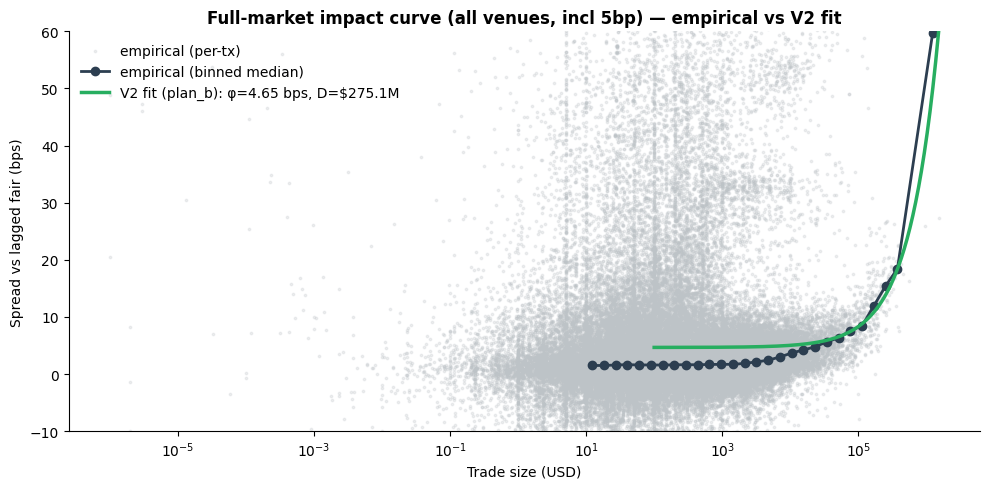

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax,
                      sample=load_allpools_impact_sample(),
                      fit=load_allpools_impact_fit(),
                      title="Full-market impact curve (all venues, incl 5bp) — empirical vs V2 fit")
plt.tight_layout()
plt.show()

**This (φ, D) is the competitor a new strategy is tested against:** plug the candidate mechanism in as the submission pool, use this full-market pool as the normalizer, and read its LP markout / edge / volume share — exactly the §5 setup, but with the new mechanism (not the 5bp pool) in the submission slot.